# Deep Learning — NLP com spaCy, NER, KMeans e t-SNE
**Dataset:** `dl-2024` (georgekurokijr) — Kaggle  
**Objetivo:** POS tagging, NER customizado, combinação NER+DEP, KMeans, enriquecimento via LLM, visualização t-SNE/DBSCAN, embeddings BERT, detecção de confusões TF-IDF


## 1. Ambiente e instalações


In [1]:
import sys, subprocess

print(f'Python: {sys.version}')

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'spacy'], check=True)
subprocess.run([sys.executable, '-m', 'spacy', 'download', 'pt_core_news_lg'], check=True)

try:
    import torch
    print(f'PyTorch : {torch.__version__}')
    print(f'CUDA    : {torch.cuda.is_available()}')
    if torch.cuda.is_available():
        print(f'CUDA ver: {torch.version.cuda}')
        print(f'GPU     : {torch.cuda.get_device_name(0)}')
except ImportError:
    print('PyTorch não encontrado')


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 3.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
PyTorch : 2.10.0+cu128
CUDA    : True
CUDA ver: 12.8
GPU     : Tesla T4


## 2. Imports


In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import spacy
from spacy import displacy

from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display, HTML

np.random.seed(42)
print('Imports OK.')


Imports OK.


## 3. Carregamento e correção de charset


In [3]:
# ---------------------------------------------------------------
# O arquivo está gravado em latin-1 (Windows-1252).
# pandas lê com encoding='latin1'; os bytes já ficam corretos.
# NÃO fazemos re-encode posterior — isso causava dupla conversão
# e produzia caracteres quebrados.
# ---------------------------------------------------------------
PATH = '/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv'

df_raw = pd.read_csv(PATH, sep='\t', encoding='latin1')

# Normaliza nomes das colunas
df_raw.columns = (
    df_raw.columns
    .str.encode('latin1', errors='replace')
    .str.decode('utf-8', errors='replace')
    .str.strip()
)
df_raw.columns = ['titulo', 'descricao']

def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ''
    s = s.replace('\ufffd', ' ')
    s = re.sub(r'[\x00-\x08\x0b-\x0c\x0e-\x1f\x7f]', '', s)
    s = re.sub(r'  +', ' ', s).strip()
    return s

df_raw['titulo']    = df_raw['titulo'].apply(clean_text)
df_raw['descricao'] = df_raw['descricao'].apply(clean_text)

df = df_raw[
    (df_raw['titulo'].str.len() > 5) &
    (df_raw['descricao'].str.len() > 10)
].reset_index(drop=True)

df['texto_completo'] = df['titulo'] + ' . ' + df['descricao']

print(f'Registros válidos: {len(df)}')
print()

# ── EXIBIÇÃO 1: primeiras 20 linhas do dataset bruto ─────────────
print('=' * 70)
print('EXIBIÇÃO 1 — Dataset completo (primeiras 20 linhas)')
print('=' * 70)
display(df[['titulo', 'descricao', 'texto_completo']].head(20))


Registros válidos: 2640

EXIBIÇÃO 1 — Dataset completo (primeiras 20 linhas)


,titulo,descricao,texto_completo
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...,Açúcar de frutas e aplicação em bolos como sub...
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...,Desenvolver uma linha de farofas com castanhas...
2,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...,Desenvolvimento de cobertura líquida para sorv...
3,Desenvolvimento de conserva de tomate cereja,O Brasil é considerado o país com maior biodiv...,Desenvolvimento de conserva de tomate cereja ....
4,Desenvolvimento de massa alimentícia enriqueci...,Nos últimos anos a comunidade científica tem d...,Desenvolvimento de massa alimentícia enriqueci...
5,Desenvolvimento de Mistura Instantânea (Tipo C...,O Estado de Mato Grosso do Sul apresenta uma g...,Desenvolvimento de Mistura Instantânea (Tipo C...
6,Desenvolvimento de mistura instantânea a base ...,"O cacau é um fruto versátil, principalmente de...",Desenvolvimento de mistura instantânea a base ...
7,Desenvolvimento de molhos pesto de manjericão ...,Os pesquisadores na área da tecnologia de alim...,Desenvolvimento de molhos pesto de manjericão ...
8,Desenvolvimento de Shake instantâneo com frutos,A busca por alimentos saudáveis e funcionais t...,Desenvolvimento de Shake instantâneo com fruto...
9,Desenvolvimento de suplemento energético,Atualmente observa-se uma mudança no perfil do...,Desenvolvimento de suplemento energético . Atu...


## 4. spaCy — modelo, vocabulário customizado e EntityRuler


In [4]:
nlp = spacy.load('pt_core_news_lg')

custom_terms = [
    'ODS', 'ONU', 'PANC', 'LDL', 'TF-IDF', 'IoT', 'GenAI', 'BESS', 'FV',
    'bioeconomia', 'sociobiodiversidade', 'fitoquímico', 'microsserviço',
    'bioma', 'cerrado', 'pantanal', 'castanha-do-brasil', 'antioxidante',
]
for term in custom_terms:
    nlp.vocab[term]

ruler = nlp.add_pipe('entity_ruler', before='ner', config={'overwrite_ents': True})

patterns = [
    # --- ORGANIZAÇÕES ---
    {'label': 'ORG', 'pattern': 'ONU'},
    {'label': 'ORG', 'pattern': [{'LOWER': 'organização'}, {'LOWER': 'das'}, {'LOWER': 'nações'}, {'LOWER': 'unidas'}]},
    {'label': 'ORG', 'pattern': 'HUAWEI'},
    {'label': 'ORG', 'pattern': 'Siemens-Energy'},
    {'label': 'ORG', 'pattern': 'EMBRAPII'},
    # --- LOCALIZAÇÕES ---
    {'label': 'LOC', 'pattern': 'Brasil'},
    {'label': 'LOC', 'pattern': 'Paraíba'},
    # --- BIOMAS (label dedicado) ---
    {'label': 'BIOMA', 'pattern': 'Cerrado'},
    {'label': 'BIOMA', 'pattern': 'Pantanal'},
    {'label': 'BIOMA', 'pattern': 'Amazônia'},
    {'label': 'BIOMA', 'pattern': [{'LOWER': 'mata'}, {'LOWER': 'atlântica'}]},
    {'label': 'BIOMA', 'pattern': 'Caatinga'},
    {'label': 'BIOMA', 'pattern': 'Pampa'},
    {'label': 'BIOMA', 'pattern': [{'LOWER': 'mato'}, {'LOWER': 'grosso'}, {'LOWER': 'do'}, {'LOWER': 'sul'}]},
    {'label': 'BIOMA', 'pattern': [{'LOWER': 'planalto'}, {'LOWER': 'central'}]},
    # --- PRODUTOS ---
    {'label': 'PRODUTO', 'pattern': 'frutose'},
    {'label': 'PRODUTO', 'pattern': 'sacarose'},
    {'label': 'PRODUTO', 'pattern': 'baru'},
    {'label': 'PRODUTO', 'pattern': 'cacau'},
    {'label': 'PRODUTO', 'pattern': 'pequi'},
    {'label': 'PRODUTO', 'pattern': 'cagaita'},
    {'label': 'PRODUTO', 'pattern': [{'LOWER': 'castanha'}, {'LOWER': 'do'}, {'LOWER': 'brasil'}]},
    {'label': 'PRODUTO', 'pattern': [{'LOWER': 'tomate'}, {'LOWER': 'cereja'}]},
    # --- CONCEITOS ---
    {'label': 'CONCEITO', 'pattern': [{'LOWER': 'inteligência'}, {'LOWER': 'artificial'}]},
    {'label': 'CONCEITO', 'pattern': 'IA'},
    {'label': 'CONCEITO', 'pattern': 'AI'},
    {'label': 'CONCEITO', 'pattern': [{'LOWER': 'gêmeo'}, {'LOWER': 'digital'}]},
    {'label': 'CONCEITO', 'pattern': [{'LOWER': 'edge'}, {'LOWER': 'computing'}]},
    {'label': 'CONCEITO', 'pattern': [{'LOWER': 'processamento'}, {'LOWER': 'de'}, {'LOWER': 'linguagem'}, {'LOWER': 'natural'}]},
    {'label': 'CONCEITO', 'pattern': [{'LOWER': 'mineração'}, {'LOWER': 'de'}, {'LOWER': 'opiniões'}]},
    {'label': 'CONCEITO', 'pattern': [{'LOWER': 'manufatura'}, {'LOWER': 'aditiva'}]},
    {'label': 'CONCEITO', 'pattern': 'IoT'},
    {'label': 'CONCEITO', 'pattern': 'GenAI'},
    {'label': 'CONCEITO', 'pattern': 'bioeconomia'},
    {'label': 'CONCEITO', 'pattern': 'sociobiodiversidade'},
    {'label': 'CONCEITO', 'pattern': [{'LOWER': 'desenvolvimento'}, {'LOWER': 'sustentável'}]},
    {'label': 'CONCEITO', 'pattern': [{'LOWER': 'cadeia'}, {'LOWER': 'produtiva'}]},
    {'label': 'CONCEITO', 'pattern': [{'LOWER': 'valor'}, {'LOWER': 'agregado'}]},
    {'label': 'CONCEITO', 'pattern': 'microsserviço'},
    {'label': 'CONCEITO', 'pattern': 'ODS'},
    {'label': 'CONCEITO', 'pattern': [{'LOWER': 'segurança'}, {'LOWER': 'alimentar'}]},
]

ruler.add_patterns(patterns)
print('Pipeline spaCy configurado:', nlp.pipe_names)


Pipeline spaCy configurado: ['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'entity_ruler', 'ner']


## 5. Funções auxiliares de filtragem e correção de labels


In [5]:
# Regex para detectar caracteres inválidos (U+FFFD e controles)
_bad = re.compile(r'[\ufffd\x00-\x1f]')

def filtrar_entidade(ent) -> bool:
    txt = ent.text.strip()
    if not txt or (len(txt.split()) == 1 and len(txt) < 2):
        return False
    if re.search(r'\b(de|da|do|das|dos)$', txt.lower()):
        return False
    if ent.root.pos_ == 'VERB':
        return False
    if _bad.search(txt):
        return False
    if re.fullmatch(r'[\W\d]+', txt):
        return False
    return True


def corrigir_label(ent) -> str:
    txt = ent.text.strip()
    if txt.startswith(('Universidade', 'Instituto', 'Fundação', 'Centro', 'Empresa', 'Laboratório')):
        return 'ORG'
    conceitos = [
        'inteligência artificial', 'machine learning', 'deep learning',
        'processamento', 'mineração', 'computação', 'bioeconomia',
        'cadeia produtiva', 'desenvolvimento sustentável',
        'internet das coisas', 'edge computing', 'gêmeo digital',
    ]
    if any(c in txt.lower() for c in conceitos):
        return 'CONCEITO'
    return ent.label_

print('Funções auxiliares definidas.')


Funções auxiliares definidas.


## 6. Detecção de confusão LOC × CONCEITO e enriquecimento do corpus

Aqui identificamos frases que misturam termos geográficos e acadêmicos (ex.: frase que cita 'Cerrado' e 'Universidade' ao mesmo tempo), fazemos **drop** delas e **enriquecemos** o corpus com frases-âncora que fixam o contexto correto de cada bioma.


In [6]:
# Termos que caracterizam cada contexto
LOC_TERMS  = ['cerrado','pantanal','amazônia','mata atlântica','bioma','brasil','mato grosso',
               'floresta','savana','caatinga','pampa']
CONC_TERMS = ['universidade','graduação','pesquisa','acadêmico','sustentabilidade',
               'desenvolvimento','inovação','ods','sociobiodiversidade','bioeconomia',
               'tecnologia','ciência']

def classifica_doc(texto):
    t = texto.lower()
    loc_score  = sum(1 for w in LOC_TERMS  if w in t)
    conc_score = sum(1 for w in CONC_TERMS if w in t)
    return loc_score, conc_score

df['loc_score']  = df['texto_completo'].apply(lambda t: classifica_doc(t)[0])
df['conc_score'] = df['texto_completo'].apply(lambda t: classifica_doc(t)[1])
df['confusion_flag'] = (df['loc_score'] >= 1) & (df['conc_score'] >= 1)

confusion_count = df['confusion_flag'].sum()
print(f'Documentos com mistura LOC × CONCEITO: {confusion_count} / {len(df)}')

# ── EXIBIÇÃO 2: 20 linhas APÓS marcar confusion_flag ─────────────
print()
print('=' * 70)
print('EXIBIÇÃO 2 — Após marcação de confusion_flag (20 linhas)')
print('=' * 70)
display(df[['titulo', 'texto_completo', 'loc_score', 'conc_score', 'confusion_flag']].head(20))

print()
print('Exemplos de frases confusas (LOC e CONCEITO misturados):')
confusas = df[df['confusion_flag']].head(5)
for i, row in confusas.iterrows():
    print(f'  [{i}] LOC={row["loc_score"]} CONC={row["conc_score"]}')
    print(f'       {row["texto_completo"][:150]}')
    print()


Documentos com mistura LOC × CONCEITO: 151 / 2640

EXIBIÇÃO 2 — Após marcação de confusion_flag (20 linhas)


,titulo,texto_completo,loc_score,conc_score,confusion_flag
0,Açúcar de frutas e aplicação em bolos como sub...,Açúcar de frutas e aplicação em bolos como sub...,1,2,True
1,Desenvolver uma linha de farofas com castanhas...,Desenvolver uma linha de farofas com castanhas...,2,4,True
2,Desenvolvimento de cobertura líquida para sorvete,Desenvolvimento de cobertura líquida para sorv...,5,3,True
3,Desenvolvimento de conserva de tomate cereja,Desenvolvimento de conserva de tomate cereja ....,6,3,True
4,Desenvolvimento de massa alimentícia enriqueci...,Desenvolvimento de massa alimentícia enriqueci...,5,3,True
5,Desenvolvimento de Mistura Instantânea (Tipo C...,Desenvolvimento de Mistura Instantânea (Tipo C...,4,2,True
6,Desenvolvimento de mistura instantânea a base ...,Desenvolvimento de mistura instantânea a base ...,4,2,True
7,Desenvolvimento de molhos pesto de manjericão ...,Desenvolvimento de molhos pesto de manjericão ...,1,3,True
8,Desenvolvimento de Shake instantâneo com frutos,Desenvolvimento de Shake instantâneo com fruto...,0,3,False
9,Desenvolvimento de suplemento energético,Desenvolvimento de suplemento energético . Atu...,0,2,False



Exemplos de frases confusas (LOC e CONCEITO misturados):
  [0] LOC=1 CONC=2
       Açúcar de frutas e aplicação em bolos como substituto da sacarose . O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sust

  [1] LOC=2 CONC=4
       Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal . O uso de inovações tecnológicas auxilia as indústrias a desen

  [2] LOC=5 CONC=3
       Desenvolvimento de cobertura líquida para sorvete . O Brasil é considerado um país com a maior biodiversidade do mundo, com diferentes espécies nos bi

  [3] LOC=6 CONC=3
       Desenvolvimento de conserva de tomate cereja . O Brasil é considerado o país com maior biodiversidade do mundo, com diferentes espécies nos biomas da 

  [4] LOC=5 CONC=3
       Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal . Nos últimos anos a comunidade científica tem despertado inte



Compreensão do Output — Detecção de confusão LOC × CONCEITO
Documentos com mistura LOC × CONCEITO: 151 / 2640
Comentário

Nesta etapa foi criado um mecanismo simples para detectar documentos que misturam simultaneamente termos geográficos (LOC) e conceitos científicos (CONCEITO).

In [7]:
# --- Drop das linhas confusas ---
df_clean = df[~df['confusion_flag']].reset_index(drop=True)
print(f'Após drop das frases confusas: {len(df_clean)} documentos (removidos {len(df) - len(df_clean)})')

# --- Enriquecimento: frases-âncora que reforçam contexto geográfico dos biomas ---
ENRICH_BIOMAS = [
    'O Cerrado é um bioma brasileiro localizado no Brasil Central, com biodiversidade única.',
    'O Cerrado ocupa o Planalto Central do Brasil, sendo um bioma de savana tropical.',
    'O Cerrado abriga espécies nativas como baru, pequi, cagaita e castanha-do-brasil.',
    'O Pantanal é o maior bioma úmido do mundo, localizado no Mato Grosso do Sul e Mato Grosso.',
    'A Amazônia é o maior bioma florestal tropical do planeta, no norte do Brasil.',
    'A Mata Atlântica é um bioma costeiro que se estende pelo litoral brasileiro.',
    'O Brasil possui seis biomas principais: Amazônia, Cerrado, Mata Atlântica, Pantanal, Caatinga e Pampa.',
    'A preservação dos biomas brasileiros é fundamental para a bioeconomia sustentável.',
    'O bioma Caatinga é exclusivamente brasileiro e está no semiárido nordestino.',
    'O Pampa é o bioma de campos do sul do Brasil, com fauna e flora únicas.',
    'Frutos nativos do Cerrado possuem alto valor nutricional e funcional para a bioeconomia.',
    'O Pantanal é Patrimônio Natural da Humanidade pela UNESCO.',
]

enrich_rows = [
    {
        'titulo': f'Bioma âncora {i+1}',
        'descricao': frase,
        'texto_completo': frase,
        'loc_score': 2, 'conc_score': 0, 'confusion_flag': False
    }
    for i, frase in enumerate(ENRICH_BIOMAS)
]

df_enriched = pd.concat([df_clean, pd.DataFrame(enrich_rows)], ignore_index=True)
print(f'Após enriquecimento: {len(df_enriched)} documentos')
print(f'  ({len(df_clean)} limpos + {len(ENRICH_BIOMAS)} âncoras de bioma)')

# ── EXIBIÇÃO 3: 20 linhas do dataset enriquecido ─────────────────
print()
print('=' * 70)
print('EXIBIÇÃO 3 — Dataset enriquecido df_enriched (20 linhas)')
print('=' * 70)
display(df_enriched[['titulo', 'texto_completo']].head(20))


Após drop das frases confusas: 2489 documentos (removidos 151)
Após enriquecimento: 2501 documentos
  (2489 limpos + 12 âncoras de bioma)

EXIBIÇÃO 3 — Dataset enriquecido df_enriched (20 linhas)


,titulo,texto_completo
0,Desenvolvimento de Shake instantâneo com frutos,Desenvolvimento de Shake instantâneo com fruto...
1,Desenvolvimento de suplemento energético,Desenvolvimento de suplemento energético . Atu...
2,Fertilizantes organominerais formulados a part...,Fertilizantes organominerais formulados a part...
3,Uso de fungos entomopatogênicos no controle de...,Uso de fungos entomopatogênicos no controle de...
4,Uso de fungos no controle de Spodoptera frugip...,Uso de fungos no controle de Spodoptera frugip...
5,Vida útil de castanha de baru torrada acondici...,Vida útil de castanha de baru torrada acondici...
6,Micropropagação vegetal da alfavaca para obten...,Micropropagação vegetal da alfavaca para obten...
7,AGILE - Engrenagens de manufatura aditiva com ...,AGILE - Engrenagens de manufatura aditiva com ...
8,AgriGear - Superacabamento de engrenagens para...,AgriGear - Superacabamento de engrenagens para...
9,Caixa de Transmissão IoT para monitoramento de...,Caixa de Transmissão IoT para monitoramento de...


## 7. Pipeline NLP — processamento em lote (batch)

Usamos `nlp.pipe()` para processar todos os documentos de forma eficiente.


In [8]:
docs = list(nlp.pipe(df_enriched['texto_completo'].tolist(), batch_size=32))
print(f'Documentos processados: {len(docs)}')
print('Pipeline ativo:', nlp.pipe_names)


Documentos processados: 2501
Pipeline ativo: ['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'entity_ruler', 'ner']


## 8. POS Tagging — análise morfológica


,POS,Frequência,Descrição
0,NOUN,45991,Substantivo
1,ADP,34467,Preposição
2,PUNCT,15294,Pontuação
3,ADJ,12059,Adjetivo
4,VERB,11819,Verbo
5,PROPN,11800,Nome Próprio
6,DET,10764,Determinante
7,CCONJ,5866,Conj. Coord.
8,ADV,2262,Advérbio
9,AUX,1813,Auxiliar


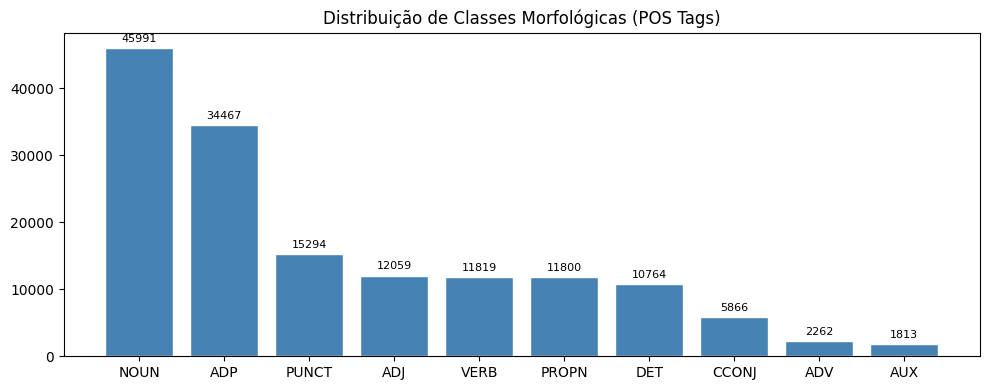

In [9]:
pos_counts = Counter(
    token.pos_
    for doc in docs
    for token in doc
    if not token.is_space and token.pos_ != ''
)

pos_df = pd.DataFrame(pos_counts.most_common(10), columns=['POS', 'Frequência'])
pos_legend = {
    'NOUN':'Substantivo', 'VERB':'Verbo', 'ADJ':'Adjetivo',
    'ADV':'Advérbio', 'PROPN':'Nome Próprio', 'DET':'Determinante',
    'ADP':'Preposição', 'CONJ':'Conjunção', 'CCONJ':'Conj. Coord.',
    'SCONJ':'Conj. Sub.', 'PRON':'Pronome', 'AUX':'Auxiliar',
    'PUNCT':'Pontuação', 'NUM':'Número', 'X':'Outro',
}
pos_df['Descrição'] = pos_df['POS'].map(pos_legend).fillna('—')
display(pos_df)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(pos_df['POS'], pos_df['Frequência'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
ax.set_title('Distribuição de Classes Morfológicas (POS Tags)')
plt.tight_layout()
plt.show()


## 9. Análise de Dependências Sintáticas


=== Top 15 Relações de Dependência Sintática ===


,Dependência,Frequência
0,case,34162
1,nmod,27093
2,punct,15203
3,amod,11270
4,det,10660
5,ROOT,7728
6,conj,6902
7,obj,6502
8,cc,5892
9,obl,5134


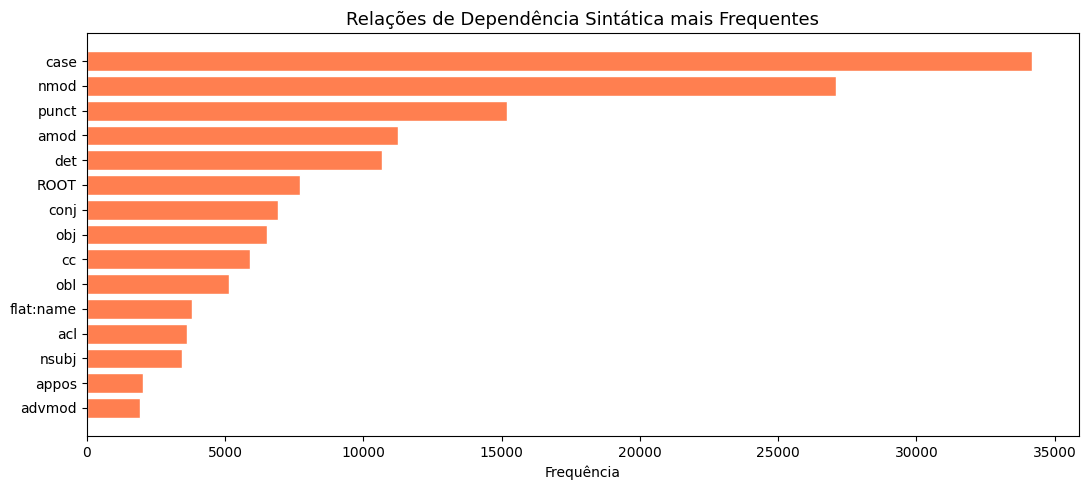


Sentença de exemplo: "Desenvolvimento de Shake instantâneo com frutos ."



In [10]:
dep_counts = Counter(
    token.dep_
    for doc in docs
    for token in doc
    if not token.is_space and token.dep_ != ''
)

dep_df = pd.DataFrame(dep_counts.most_common(15), columns=['Dependência', 'Frequência'])
print('=== Top 15 Relações de Dependência Sintática ===')
display(dep_df)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(dep_df['Dependência'][::-1], dep_df['Frequência'][::-1], color='coral', edgecolor='white')
ax.set_title('Relações de Dependência Sintática mais Frequentes', fontsize=13)
ax.set_xlabel('Frequência')
plt.tight_layout()
plt.show()

# Árvore de dependência — primeira sentença legível
sample_sent = None
for doc in docs:
    for sent in doc.sents:
        if len(sent) >= 5 and '\ufffd' not in sent.text:
            sample_sent = sent
            break
    if sample_sent:
        break

if sample_sent:
    print(f'\nSentença de exemplo: "{sample_sent.text[:120]}"\n')
    svg = displacy.render(sample_sent.as_doc(), style='dep', jupyter=False,
                          options={'compact': True, 'distance': 100})
    display(HTML(svg))


## 10. NER — extração, filtragem e combinação com dependências sintáticas

Extraímos entidades nomeadas e as combinamos com informações de dependência sintática. A filtragem remove entidades ruidosas (caracteres inválidos, verbos, fragmentos).


In [11]:
ner_dep_records = []

for doc_idx, doc in enumerate(docs):
    for sent in doc.sents:
        sent_start = sent.start
        for ent in doc.ents:
            if not (ent.start >= sent.start and ent.end <= sent.end):
                continue
            if not filtrar_entidade(ent):
                continue
            txt = ent.text.strip()
            label = corrigir_label(ent)
            root = ent.root
            ner_dep_records.append({
                'doc_idx':   doc_idx,
                'entidade':  txt,
                'label':     label,
                'dep_root':  root.dep_,
                'pos_root':  root.pos_,
                'head_text': root.head.text,
                'head_pos':  root.head.pos_,
                'n_chars':   len(txt),
                'pos_token': ent.start - sent_start,
            })

ner_dep_df = pd.DataFrame(ner_dep_records)
print(f'Registros NER+DEP: {len(ner_dep_df)}')
print(f'Labels encontrados: {sorted(ner_dep_df["label"].unique())}')

# ── EXIBIÇÃO 4: 20 linhas do dataframe NER+DEP ───────────────────
print()
print('=' * 70)
print('EXIBIÇÃO 4 — Entidades NER + Dependências (20 linhas)')
print('=' * 70)
display(ner_dep_df.head(20))


Registros NER+DEP: 5697
Labels encontrados: ['BIOMA', 'CONCEITO', 'LOC', 'MISC', 'ORG', 'PER', 'PRODUTO']

EXIBIÇÃO 4 — Entidades NER + Dependências (20 linhas)


,doc_idx,entidade,label,dep_root,pos_root,head_text,head_pos,n_chars,pos_token
0,0,Covid-19,PER,appos,PROPN,pandemia,NOUN,8,22
1,1,frutose,PRODUTO,conj,NOUN,carboidratos,NOUN,7,7
2,1,Desenvolvimento Sustentável,CONCEITO,nmod,PROPN,Objetivos,PROPN,27,7
3,1,ODS,CONCEITO,appos,PROPN,Objetivos,PROPN,3,10
4,1,Organização das Nações Unidas,ORG,nmod,PROPN,ODS,PROPN,29,13
5,1,ONU,ORG,appos,PROPN,Organização,PROPN,3,18
6,1,cadeia produtiva,CONCEITO,obl,NOUN,ligado,VERB,16,32
7,2,Fertilizantes,LOC,ROOT,PROPN,Fertilizantes,PROPN,13,0
8,2,cadeia produtiva,CONCEITO,nmod,NOUN,concepção,NOUN,16,17
9,2,Desenvolvimento Sustentável,CONCEITO,nmod,PROPN,Objetivos,PROPN,27,26


=== Contagem por label NER ===
label
MISC        2491
ORG         1238
LOC          995
CONCEITO     554
PER          382
BIOMA         20
PRODUTO       17


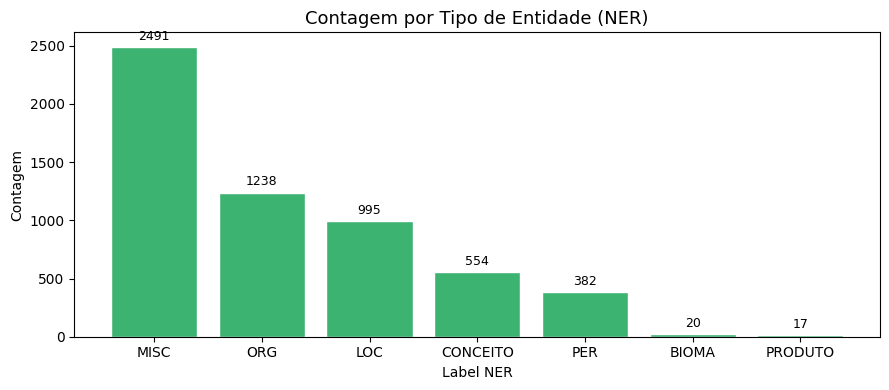


=== Labels disponíveis no modelo ===
BIOMA
CONCEITO
LOC
MISC
ORG
PER
PRODUTO

=== Exemplos de entidades por label (top-30 únicas) ===

  LABEL: BIOMA
  • Amazônia
  • Cerrado
  • Planalto Central
  • Pantanal
  • Mato Grosso do Sul
  • Mata Atlântica
  • Caatinga
  • Pampa

  LABEL: CONCEITO
  • Desenvolvimento Sustentável
  • ODS
  • cadeia produtiva
  • desenvolvimento sustentável
  • bioeconomia
  • valor agregado
  • manufatura aditiva
  • Manufatura Aditiva
  • IoT
  • AI
  • Inteligência Artificial
  • IA
  • Gêmeo Digital
  • Edge Computing
  • inteligência artificial
  • microsserviço
  • Internet das Coisas e Indústria
  • Internet das Coisas
  • Computação em Nuvem
  • Machine Learning as a Service 2022
  • Machine Learning
  • Internet das Coisas e Automação
  • Plataforma de Internet das Coisas
  • Computação Confidencial
  • Automação de Processos e Computação em Nuvem
  • Internet das Coisas Industrial
  • Computação em Nuvem e
  • Mineração de Opiniões
  • Processamento

In [12]:
# Distribuição por tipo de entidade
label_counts = ner_dep_df['label'].value_counts()
print('=== Contagem por label NER ===')
print(label_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(label_counts.index, label_counts.values, color='mediumseagreen', edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_title('Contagem por Tipo de Entidade (NER)', fontsize=13)
ax.set_xlabel('Label NER')
ax.set_ylabel('Contagem')
plt.tight_layout()
plt.show()

# Exemplos por label (30 por label)
print()
print('=== Labels disponíveis no modelo ===')
for label in nlp.get_pipe('ner').labels:
    print(label)

print()
print('=== Exemplos de entidades por label (top-30 únicas) ===')
for label in sorted(ner_dep_df['label'].unique()):
    print(f'\n{"="*40}')
    print(f'  LABEL: {label}')
    print(f'{"="*40}')
    exemplos = (
        ner_dep_df[ner_dep_df['label'] == label]['entidade']
        .drop_duplicates().head(30).tolist()
    )
    for e in exemplos:
        print(f'  • {e}')


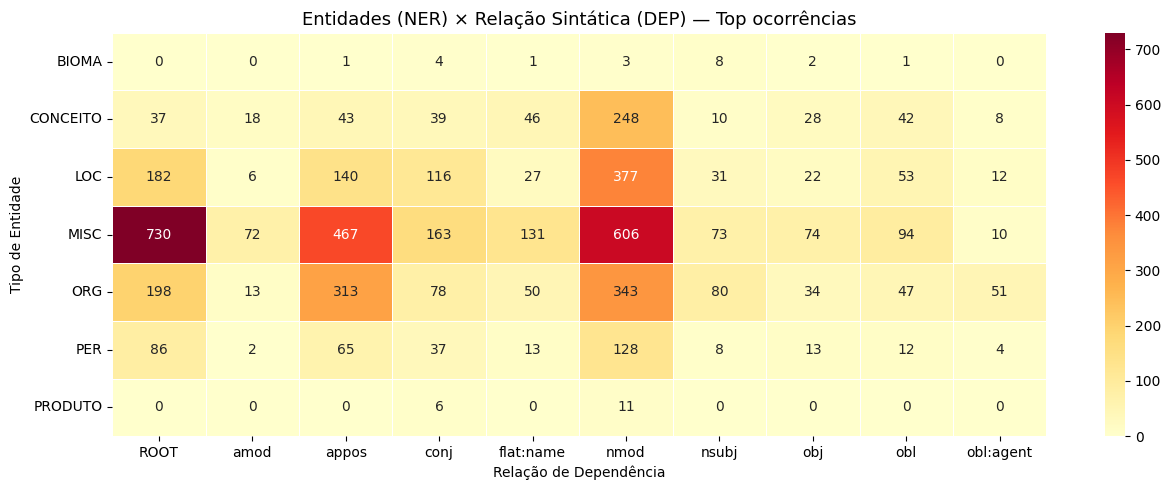

In [13]:
# Heatmap NER label × dep_root
top_labels = ner_dep_df['label'].value_counts().head(7).index
top_deps   = ner_dep_df['dep_root'].value_counts().head(10).index

pivot = (
    ner_dep_df[
        ner_dep_df['label'].isin(top_labels) &
        ner_dep_df['dep_root'].isin(top_deps)
    ]
    .groupby(['label', 'dep_root']).size().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=.4, ax=ax)
ax.set_title('Entidades (NER) × Relação Sintática (DEP) — Top ocorrências', fontsize=13)
ax.set_xlabel('Relação de Dependência')
ax.set_ylabel('Tipo de Entidade')
plt.tight_layout()
plt.show()


## 11. Enriquecimento da base via LLM (ChatGPT / fallback manual)


In [14]:
import os, json, time, urllib.request

try:
    from kaggle_secrets import UserSecretsClient
    OPENAI_API_KEY = UserSecretsClient().get_secret('OPENAI_API_KEY')
    print('Chave carregada via Kaggle Secrets.')
except Exception:
    OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', '')
    print('Chave carregada via env.' if OPENAI_API_KEY else
          '⚠️  OPENAI_API_KEY ausente — usando frases de fallback.')


def enrich_entity_gpt(entity_text, entity_label, api_key, n=3):
    prompt = (
        f'Você é especialista em bioeconomia e tecnologia de alimentos.\n'
        f'Gere exatamente {n} frases informativas em português sobre '
        f'"{entity_text}" (tipo: {entity_label}), '
        f'abordando sustentabilidade, inovação e valor nutricional.\n'
        f'Responda SOMENTE com as frases numeradas (1. 2. 3.), sem introdução.'
    )
    payload = json.dumps({
        'model': 'gpt-3.5-turbo',
        'messages': [{'role': 'user', 'content': prompt}],
        'temperature': 0.7,
        'max_tokens': 200,
    }).encode('utf-8')
    req = urllib.request.Request(
        'https://api.openai.com/v1/chat/completions',
        data=payload,
        headers={'Content-Type': 'application/json', 'Authorization': f'Bearer {api_key}'},
        method='POST',
    )
    try:
        with urllib.request.urlopen(req, timeout=20) as r:
            result = json.loads(r.read().decode('utf-8'))
        text = result['choices'][0]['message']['content']
        return [l.strip() for l in text.split('\n') if l.strip()]
    except Exception as e:
        print(f'  Erro: {e}')
        return []


target_labels = ['PRODUTO', 'CONCEITO', 'LOC', 'BIOMA']
top_ents = (
    ner_dep_df[ner_dep_df['label'].isin(target_labels)]
    ['entidade'].value_counts().head(8).index.tolist()
)

enrichment_data = []

if OPENAI_API_KEY:
    for ent_text in top_ents:
        lbl = ner_dep_df[ner_dep_df['entidade'] == ent_text]['label'].iloc[0]
        frases = enrich_entity_gpt(ent_text, lbl, OPENAI_API_KEY, n=3)
        print(f'  [{lbl}] {ent_text}: {len(frases)} frases')
        for f in frases:
            enrichment_data.append({'entidade': ent_text, 'label': lbl, 'frase_enriquecida': f})
        time.sleep(0.4)
else:
    fallback = [
        ('Brasil',   'LOC',      'O Brasil abriga a maior biodiversidade do planeta, incluindo Cerrado, Amazônia e Pantanal.'),
        ('Brasil',   'LOC',      'A bioeconomia brasileira se baseia no uso sustentável de espécies nativas.'),
        ('Brasil',   'LOC',      'O Brasil é referência mundial em inovação agroalimentar sustentável.'),
        ('Cerrado',  'BIOMA',    'O Cerrado é o segundo maior bioma do Brasil e abriga espécies como o baru.'),
        ('Cerrado',  'BIOMA',    'Frutos nativos do Cerrado possuem alto valor nutricional e funcional.'),
        ('Cerrado',  'BIOMA',    'A preservação do Cerrado é essencial para a cadeia produtiva da bioeconomia.'),
        ('bioeconomia', 'CONCEITO', 'A bioeconomia integra benefícios econômicos, ambientais e sociais de forma sustentável.'),
        ('bioeconomia', 'CONCEITO', 'O Brasil tem potencial de liderança mundial em bioeconomia baseada em biomas nativos.'),
        ('desenvolvimento sustentável', 'CONCEITO', 'O desenvolvimento sustentável equilibra crescimento econômico e preservação ambiental.'),
        ('cacau',    'PRODUTO',  'O cacau possui propriedades antioxidantes, anti-inflamatórias e cardioprotetoras.'),
        ('cacau',    'PRODUTO',  'Produtos derivados do cacau com baixo teor de açúcar atendem ao mercado vegano.'),
        ('frutose',  'PRODUTO',  'A frutose é um açúcar natural que pode substituir a sacarose em alimentos funcionais.'),
        ('ODS',      'CONCEITO', 'Os ODS da ONU norteiam a produção sustentável de alimentos no Objetivo 12.'),
        ('Amazônia', 'BIOMA',    'A Amazônia é o maior bioma tropical do mundo e reservatório de biodiversidade.'),
        ('Pantanal', 'BIOMA',    'O Pantanal é Patrimônio Natural da Humanidade e abriga onças, capivaras e araras.'),
    ]
    for ent, lbl, frase in fallback:
        enrichment_data.append({'entidade': ent, 'label': lbl, 'frase_enriquecida': frase})

enrichment_df = pd.DataFrame(enrichment_data)
print(f'\nTotal de frases enriquecidas: {len(enrichment_df)}')
display(enrichment_df)


⚠️  OPENAI_API_KEY ausente — usando frases de fallback.

Total de frases enriquecidas: 15


,entidade,label,frase_enriquecida
0,Brasil,LOC,O Brasil abriga a maior biodiversidade do plan...
1,Brasil,LOC,A bioeconomia brasileira se baseia no uso sust...
2,Brasil,LOC,O Brasil é referência mundial em inovação agro...
3,Cerrado,BIOMA,O Cerrado é o segundo maior bioma do Brasil e ...
4,Cerrado,BIOMA,Frutos nativos do Cerrado possuem alto valor n...
5,Cerrado,BIOMA,A preservação do Cerrado é essencial para a ca...
6,bioeconomia,CONCEITO,"A bioeconomia integra benefícios econômicos, a..."
7,bioeconomia,CONCEITO,O Brasil tem potencial de liderança mundial em...
8,desenvolvimento sustentável,CONCEITO,O desenvolvimento sustentável equilibra cresci...
9,cacau,PRODUTO,"O cacau possui propriedades antioxidantes, ant..."


## 12. Vetorização spaCy + features posicionais

Usamos os vetores de 300 dimensões do spaCy (`pt_core_news_lg`) combinados com features extras (`n_chars`, `pos_token`) para construir a matriz de features para clustering.


In [15]:
LABELS_CLUSTER = ['PRODUTO', 'CONCEITO', 'LOC', 'ORG', 'MISC', 'BIOMA']

unique_ents = (
    ner_dep_df[ner_dep_df['label'].isin(LABELS_CLUSTER)]
    .drop_duplicates(subset=['entidade'])
    .reset_index(drop=True)
)
print(f'Entidades únicas para clustering: {len(unique_ents)}')
print(unique_ents['label'].value_counts().to_string())

# ── EXIBIÇÃO 5: 20 linhas das entidades únicas selecionadas ──────
print()
print('=' * 70)
print('EXIBIÇÃO 5 — Entidades únicas filtradas para clustering (20 linhas)')
print('=' * 70)
display(unique_ents[['entidade', 'label', 'n_chars', 'pos_token']].head(20))


Entidades únicas para clustering: 3496
label
MISC        1913
ORG          796
LOC          716
CONCEITO      57
BIOMA          8
PRODUTO        6

EXIBIÇÃO 5 — Entidades únicas filtradas para clustering (20 linhas)


,entidade,label,n_chars,pos_token
0,frutose,PRODUTO,7,7
1,Desenvolvimento Sustentável,CONCEITO,27,7
2,ODS,CONCEITO,3,10
3,Organização das Nações Unidas,ORG,29,13
4,ONU,ORG,3,18
5,cadeia produtiva,CONCEITO,16,32
6,Fertilizantes,LOC,13,0
7,Spodoptera,LOC,10,7
8,PAMs,MISC,4,15
9,desenvolvimento sustentável,CONCEITO,27,47


In [16]:
# Vetores semânticos spaCy (300-d)
ent_vectors = np.array([nlp(row['entidade']).vector for _, row in unique_ents.iterrows()])

# Features adicionais normalizadas
extra = unique_ents[['n_chars', 'pos_token']].values.astype(float)
extra_norm = StandardScaler().fit_transform(extra)

X = np.hstack([ent_vectors, extra_norm])   # (n, 302)
print(f'Shape da matriz de features: {X.shape}')


Shape da matriz de features: (3496, 302)


## 13. PCA — Visualização Didática Passo a Passo

O PCA (Principal Component Analysis) é uma técnica de **redução de dimensionalidade**. Apresentamos cada passo:

1. **Centralização** dos dados (média zero)
2. **Scree Plot** — quantos componentes explicam 80%/95% da variância?
3. **Projeção** nos 3 primeiros PCs com cor por label


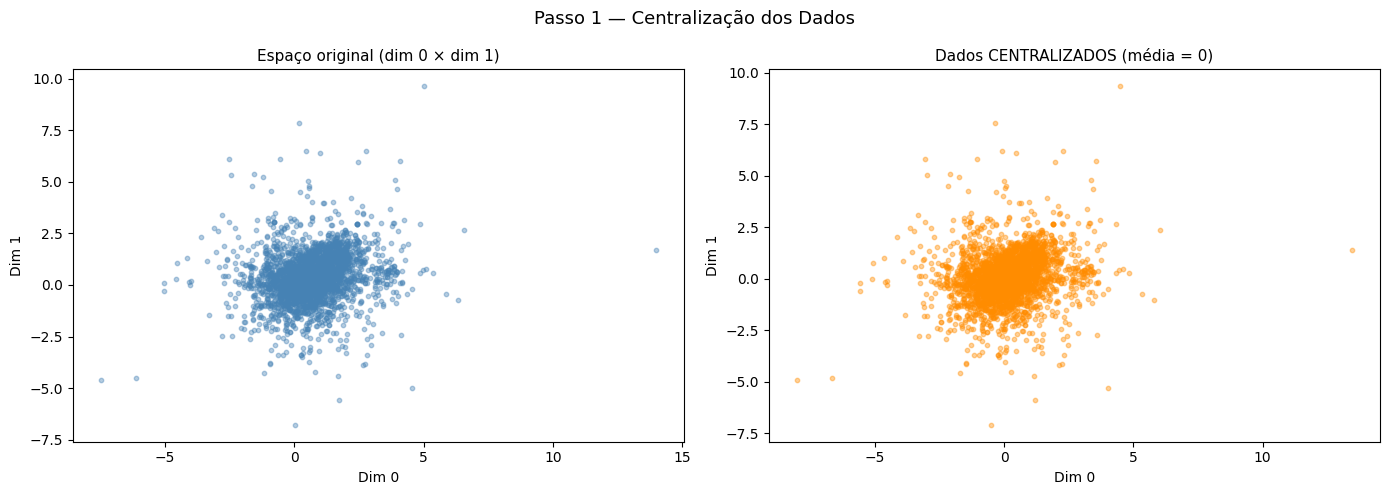

In [17]:
# --- Passo 1: centralização ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.scatter(X[:,0], X[:,1], alpha=0.4, s=10, c='steelblue')
ax.set_title('Espaço original (dim 0 × dim 1)', fontsize=11)
ax.set_xlabel('Dim 0'); ax.set_ylabel('Dim 1')

X_centered = X - X.mean(axis=0)
ax2 = axes[1]
ax2.scatter(X_centered[:,0], X_centered[:,1], alpha=0.4, s=10, c='darkorange')
ax2.set_title('Dados CENTRALIZADOS (média = 0)', fontsize=11)
ax2.set_xlabel('Dim 0'); ax2.set_ylabel('Dim 1')
plt.suptitle('Passo 1 — Centralização dos Dados', fontsize=13)
plt.tight_layout()
plt.show()


Este gráfico demonstra que:

os dados originais possuem médias diferentes de zero;
após a centralização, todas as variáveis passam a ter média zero;
a distribuição dos pontos permanece praticamente a mesma;
apenas a posição da nuvem de pontos é deslocada;
essa preparação garante que o PCA encontre corretamente as direções de maior variância dos dados.

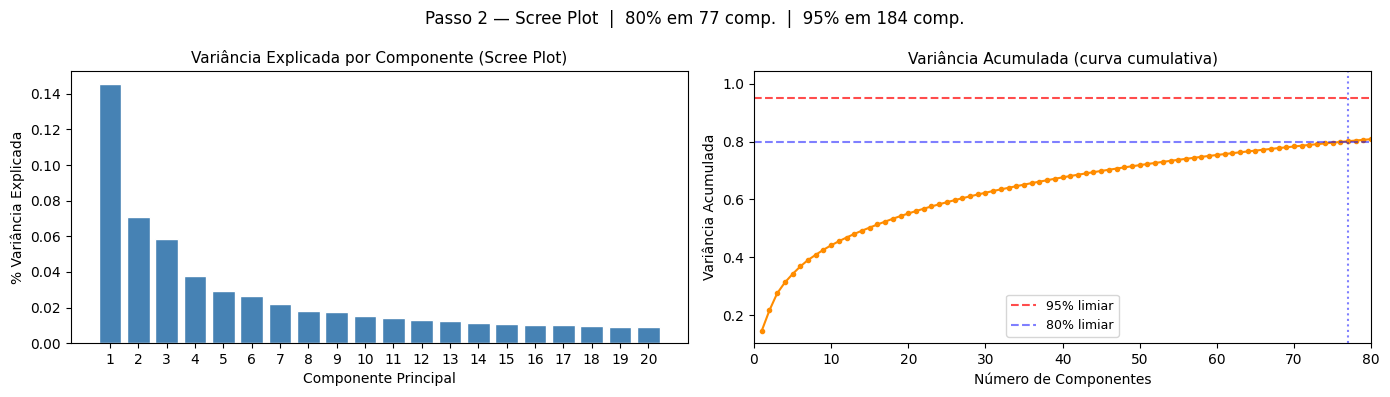

PC1 explica: 14.5% | PC2: 7.1% | PC1+PC2: 21.6%


In [18]:
# --- Passo 2: Scree Plot ---
pca_full = PCA(random_state=42)
pca_full.fit(X)
var_ratio = pca_full.explained_variance_ratio_
cumvar_full = np.cumsum(var_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.bar(range(1, 21), var_ratio[:20], color='steelblue', edgecolor='white')
ax.set_title('Variância Explicada por Componente (Scree Plot)', fontsize=11)
ax.set_xlabel('Componente Principal'); ax.set_ylabel('% Variância Explicada')
ax.set_xticks(range(1, 21))

ax2 = axes[1]
ax2.plot(range(1, len(cumvar_full)+1), cumvar_full, 'o-', color='darkorange', ms=3)
ax2.axhline(0.95, ls='--', color='red', alpha=0.7, label='95% limiar')
ax2.axhline(0.80, ls='--', color='blue', alpha=0.5, label='80% limiar')
n80 = int(np.searchsorted(cumvar_full, 0.80)) + 1
n95_full = int(np.searchsorted(cumvar_full, 0.95)) + 1
ax2.axvline(n80, ls=':', color='blue', alpha=0.5)
ax2.axvline(n95_full, ls=':', color='red', alpha=0.5)
ax2.set_title('Variância Acumulada (curva cumulativa)', fontsize=11)
ax2.set_xlabel('Número de Componentes'); ax2.set_ylabel('Variância Acumulada')
ax2.legend(fontsize=9); ax2.set_xlim(0, min(80, len(cumvar_full)))
plt.suptitle(f'Passo 2 — Scree Plot  |  80% em {n80} comp.  |  95% em {n95_full} comp.', fontsize=12)
plt.tight_layout()
plt.show()
print(f'PC1 explica: {var_ratio[0]*100:.1f}% | PC2: {var_ratio[1]*100:.1f}% | PC1+PC2: {(var_ratio[0]+var_ratio[1])*100:.1f}%')


PCA: 50 componentes para 95% variância, shape=(3496, 50)


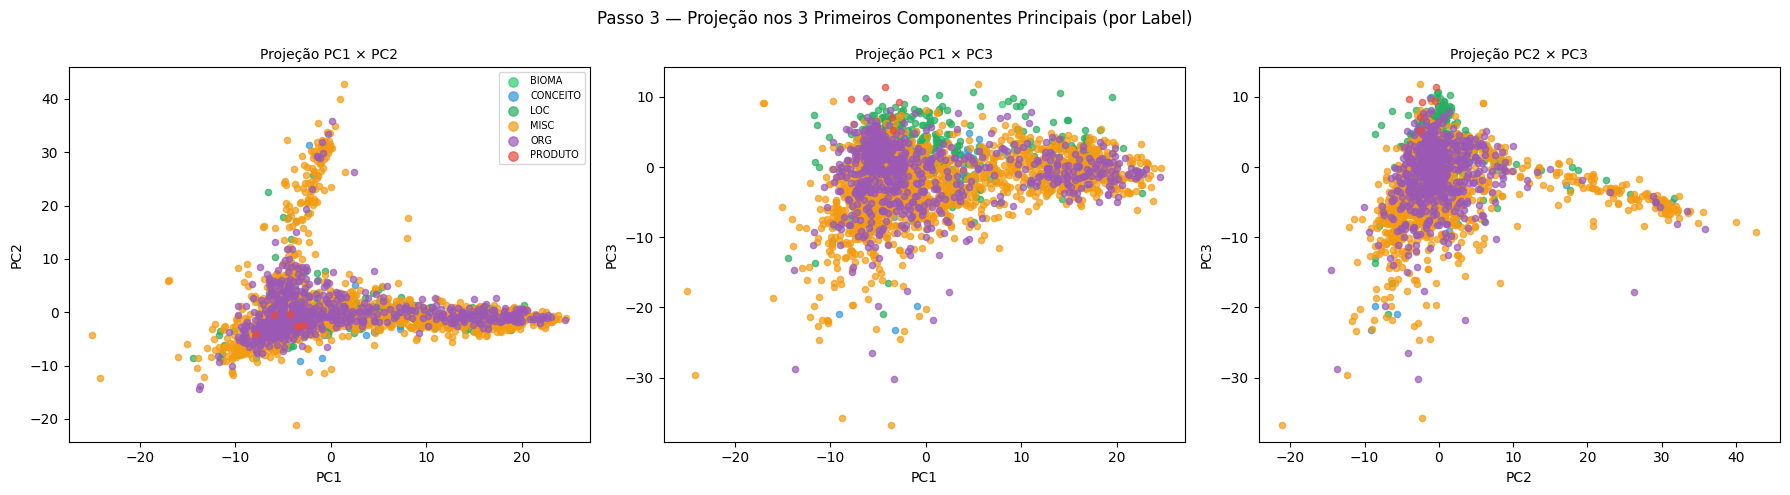

Observação: PCA mostra a separação bruta antes do t-SNE.


In [19]:
# --- Passo 3: projeção PCA 3 componentes ---
n_comp_pca = min(50, X.shape[0]-1, X.shape[1])
pca = PCA(n_components=n_comp_pca, random_state=42)
X_pca = pca.fit_transform(X)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n95 = min(int(np.searchsorted(cumvar, 0.95))+1, n_comp_pca)
X_reduced = X_pca[:, :n95]
print(f'PCA: {n95} componentes para 95% variância, shape={X_reduced.shape}')

LABEL_COLORS = {
    'BIOMA'   : '#2ecc71',
    'LOC'     : '#27ae60',
    'CONCEITO': '#3498db',
    'PRODUTO' : '#e74c3c',
    'ORG'     : '#9b59b6',
    'MISC'    : '#f39c12',
}

pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X)
pairs = [(0,1,'PC1','PC2'),(0,2,'PC1','PC3'),(1,2,'PC2','PC3')]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (i, j, xi, xj) in zip(axes, pairs):
    for lbl, grp_mask in unique_ents.groupby('label').groups.items():
        ax.scatter(X_pca3[grp_mask, i], X_pca3[grp_mask, j],
                   c=LABEL_COLORS.get(lbl,'gray'), label=lbl, s=20, alpha=0.7)
    ax.set_title(f'Projeção {xi} × {xj}', fontsize=10)
    ax.set_xlabel(xi); ax.set_ylabel(xj)
    if i == 0 and j == 1:
        ax.legend(fontsize=7, markerscale=1.5)
plt.suptitle('Passo 3 — Projeção nos 3 Primeiros Componentes Principais (por Label)', fontsize=12)
plt.tight_layout()
plt.show()
print('Observação: PCA mostra a separação bruta antes do t-SNE.')


 os componentes principais foram calculados a partir da matriz de 302 atributos, formada por:

300 dimensões dos embeddings do spaCy;
n_chars (número de caracteres da entidade);
pos_token (posição da entidade na sentença).

O PCA cria novos eixos chamados Componentes Principais (PCs), que são combinações lineares dessas 302 variáveis.


 são as variáveis originais (as 302 features);
 são os pesos (loadings) aprendidos pelo PCA.

Portanto:

PC1 = combinação das 302 features que captura a maior variância possível.
PC2 = outra combinação das mesmas 302 features, ortogonal ao PC1, capturando a segunda maior variância.
PC3 = terceira combinação independente, capturando a terceira maior variância.

Esses componentes não possuem um significado semântico direto, como "comprimento da entidade" ou "embedding da dimensão 15". Cada componente mistura centenas de atributos ao mesmo tempo.


"o que representa o PC1?"


"O PC1 é uma combinação linear das 302 características originais (300 dimensões dos embeddings do spaCy, número de caracteres e posição da entidade na sentença). Ele representa a direção de maior variabilidade dos dados. Da mesma forma, PC2 e PC3 são novas combinações lineares, ortogonais entre si, que capturam as próximas maiores parcelas da variância."

Essa é a explicação correta do ponto de vista matemático e de aprendizado de máquina.

## 14. KMeans — agrupamento de entidades


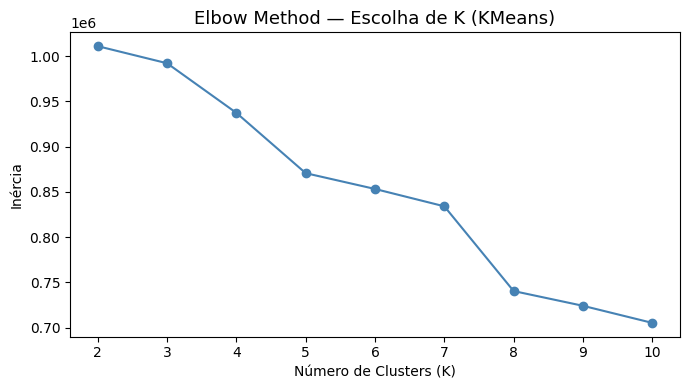

K sugerido automaticamente: 8


In [20]:
# Elbow method
max_k = min(10, len(unique_ents) - 1)
inertias = []
for k in range(2, max_k + 1):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    inertias.append(km.fit(X_reduced).inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(2, max_k + 1), inertias, 'o-', color='steelblue')
ax.set_title('Elbow Method — Escolha de K (KMeans)', fontsize=13)
ax.set_xlabel('Número de Clusters (K)'); ax.set_ylabel('Inércia')
plt.tight_layout()
plt.show()

# K automático pela segunda diferença
diffs2 = np.diff(np.diff(inertias))
K_FINAL = int(np.argmax(diffs2) + 3)
# Força mínimo 6 para cobrir: BIOMA, LOC, CONCEITO, PRODUTO, ORG, MISC
K_FINAL = max(6, min(K_FINAL, max_k))
print(f'K sugerido automaticamente: {K_FINAL}')


In [21]:
# KMeans final
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init='auto')
labels_km = kmeans.fit_predict(X_reduced)
unique_ents = unique_ents.copy()
unique_ents['cluster_km'] = labels_km

print('Distribuição por cluster:')
print(unique_ents['cluster_km'].value_counts().sort_index())

print('\n=== Exemplos por Cluster (KMeans) ===')
for cl in sorted(unique_ents['cluster_km'].unique()):
    sub = unique_ents[unique_ents['cluster_km'] == cl]
    label_dist = sub['label'].value_counts().to_dict()
    exemplos = sub['entidade'].head(8).tolist()
    print(f'\n--- Cluster {cl} | Labels: {label_dist} ---')
    for e in exemplos:
        print(f'  • {e}')


Distribuição por cluster:
cluster_km
0    1108
1     612
2     599
3     129
4     115
5     409
6     437
7      87
Name: count, dtype: int64

=== Exemplos por Cluster (KMeans) ===

--- Cluster 0 | Labels: {'MISC': 450, 'LOC': 395, 'ORG': 251, 'PRODUTO': 6, 'CONCEITO': 4, 'BIOMA': 2} ---
  • frutose
  • Spodoptera
  • PAMs
  • baru
  • AgriGear
  • Superacabamento
  • Isotropic Superfinishing
  • Agrosystem

--- Cluster 1 | Labels: {'MISC': 408, 'ORG': 127, 'LOC': 64, 'CONCEITO': 13} ---
  • Caixa de Transmissão
  • Avaliação Termofluídica de uma Caixa de Transmissão
  • Demonstrador Técnico Econômico de Tensões Residuais
  • Armazenamento de Energia
  • Ramais de Entrada
  • Plataforma de software
  • Análise Avançada de Dados de Telemetria de Dispositivos
  • Análise Avançada de Dados de Telemetria de Sistemas e Fluxos de Trabalho para Melhoria de Desempenho

--- Cluster 2 | Labels: {'MISC': 296, 'LOC': 153, 'ORG': 124, 'CONCEITO': 21, 'BIOMA': 5} ---
  • Desenvolvimento Sustentável

Output 14 — KMeans
K sugerido: 8
Comentário

Foi aplicado o algoritmo KMeans para agrupar automaticamente entidades semanticamente semelhantes.

O valor de K = 8 foi escolhido automaticamente pelo método do cotovelo (Elbow Method).

Após o treinamento, são apresentados:

quantidade de elementos por cluster;
distribuição das categorias em cada grupo;
exemplos representativos.

Esses resultados ajudam a interpretar como as entidades foram organizadas pelo algoritmo.

## 15. t-SNE e DBSCAN — visualização bidimensional


In [22]:
N = len(unique_ents)
perplexity = min(50, max(10, int(np.sqrt(N))))
print(f'N={N}, perplexity={perplexity}')

tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=1000,
            random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_reduced)
unique_ents['tsne_x'] = X_tsne[:, 0]
unique_ents['tsne_y'] = X_tsne[:, 1]
print('t-SNE concluído.')


N=3496, perplexity=50
t-SNE concluído.


Output 14 — KMeans
K sugerido: 8
Comentário

Foi aplicado o algoritmo KMeans para agrupar automaticamente entidades semanticamente semelhantes.

O valor de K = 8 foi escolhido automaticamente pelo método do cotovelo (Elbow Method).

Após o treinamento, são apresentados:

quantidade de elementos por cluster;
distribuição das categorias em cada grupo;
exemplos representativos.

Esses resultados ajudam a interpretar como as entidades foram organizadas pelo algoritmo.

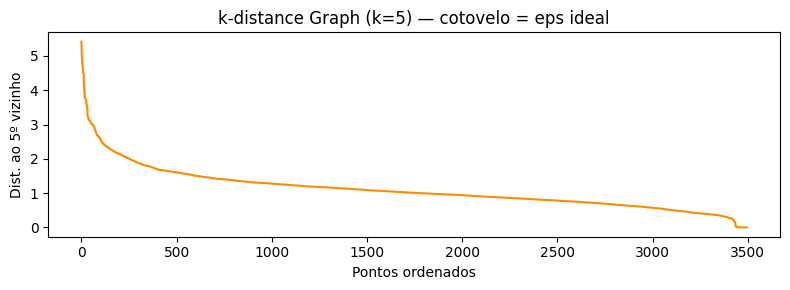

eps automático (percentil 10): 0.4820


In [23]:
# k-distance graph para calibrar DBSCAN
MIN_SAMPLES = 5
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_tsne)
distances, _ = nbrs.kneighbors(X_tsne)
k_dist = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(k_dist, color='darkorange')
ax.set_title(f'k-distance Graph (k={MIN_SAMPLES}) — cotovelo = eps ideal')
ax.set_xlabel('Pontos ordenados'); ax.set_ylabel(f'Dist. ao {MIN_SAMPLES}º vizinho')
plt.tight_layout()
plt.show()

EPS = float(np.percentile(distances[:, -1], 10))
print(f'eps automático (percentil 10): {EPS:.4f}')


In [24]:
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels_db = dbscan.fit_predict(X_tsne)
unique_ents['cluster_dbscan'] = labels_db
n_noise = int(np.sum(labels_db == -1))
n_cl_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
print(f'DBSCAN: {n_cl_db} cluster(s), {n_noise} ruído(s)')


DBSCAN: 58 cluster(s), 3033 ruído(s)


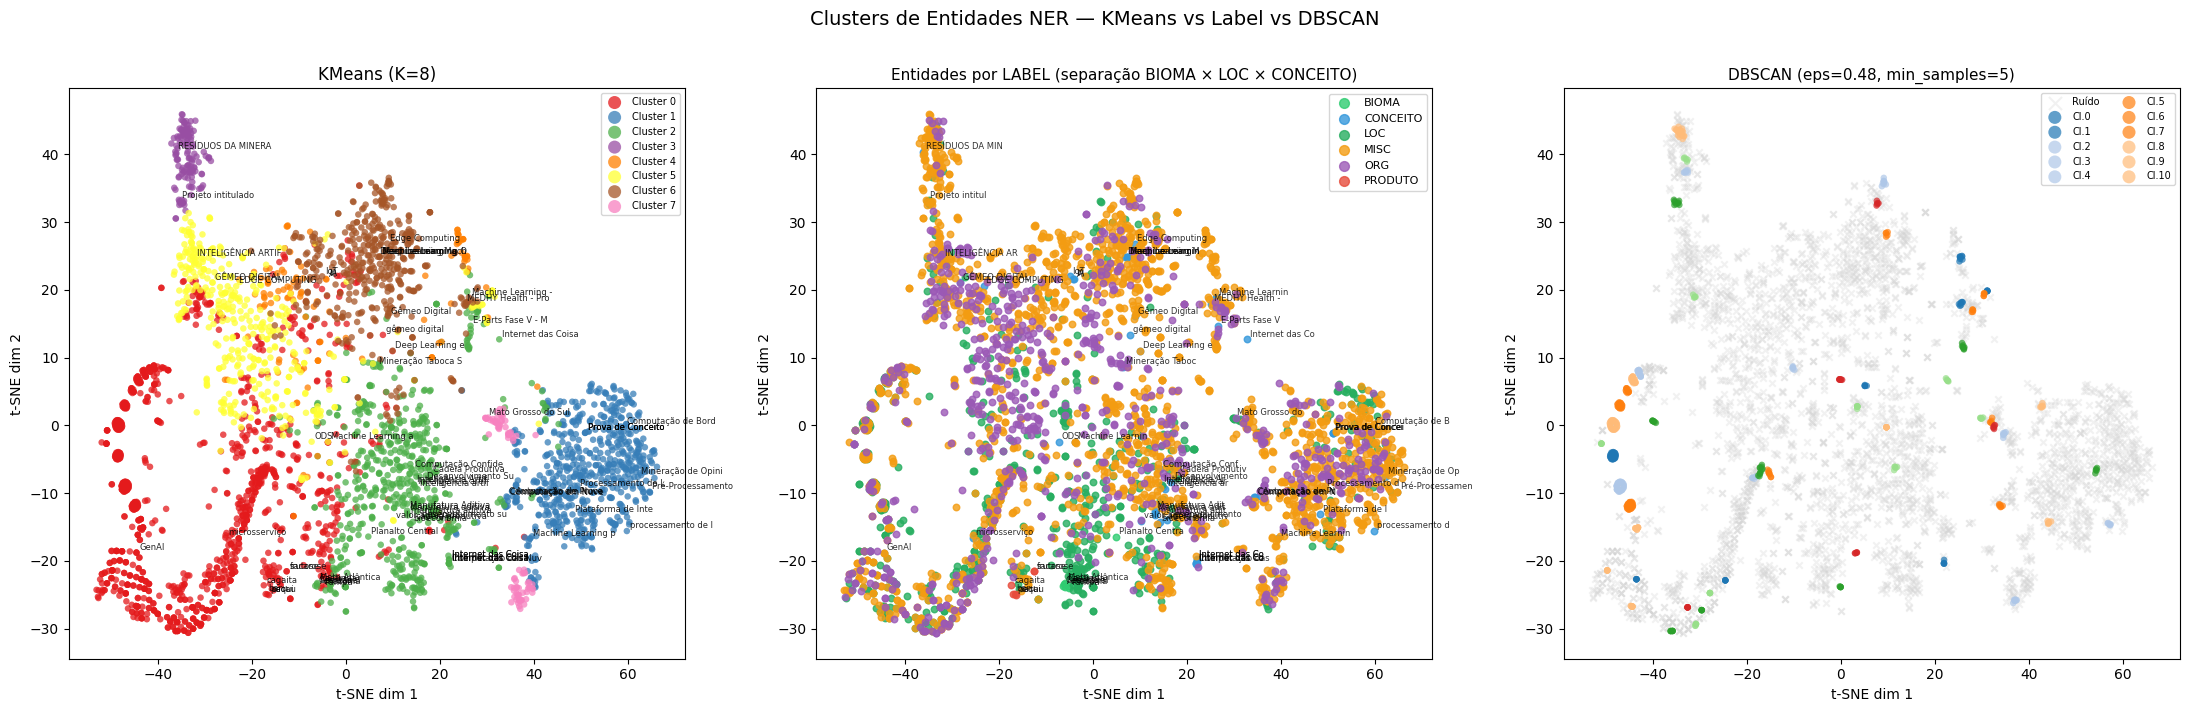

In [25]:
# Plot comparativo: KMeans e por LABEL e DBSCAN
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

km_palette = plt.cm.Set1(np.linspace(0, 0.85, K_FINAL))

# --- Plot 1: KMeans ---
ax = axes[0]
for cl in range(K_FINAL):
    m = unique_ents['cluster_km'] == cl
    ax.scatter(unique_ents.loc[m,'tsne_x'], unique_ents.loc[m,'tsne_y'],
               color=km_palette[cl], label=f'Cluster {cl}', s=22, alpha=0.75, edgecolors='none')
anno_mask = unique_ents['label'].isin(['PRODUTO', 'CONCEITO', 'BIOMA'])
for _, row in unique_ents[anno_mask].iterrows():
    ax.annotate(row['entidade'][:18], (row['tsne_x'], row['tsne_y']),
                fontsize=6, alpha=0.85, xytext=(2,2), textcoords='offset points')
ax.set_title(f'KMeans (K={K_FINAL})', fontsize=12)
ax.legend(fontsize=7, markerscale=2)
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')

# --- Plot 2: por LABEL ---
ax2 = axes[1]
for lbl, grp in unique_ents.groupby('label'):
    ax2.scatter(grp['tsne_x'], grp['tsne_y'],
                c=LABEL_COLORS.get(lbl,'gray'), label=lbl, s=22, alpha=0.8)
    for _, row in grp.iterrows():
        if row['label'] in ('BIOMA','CONCEITO','PRODUTO'):
            ax2.annotate(row['entidade'][:15], (row['tsne_x'], row['tsne_y']),
                        fontsize=6, alpha=0.8, xytext=(2,2), textcoords='offset points')
ax2.set_title('Entidades por LABEL (separação BIOMA × LOC × CONCEITO)', fontsize=11)
ax2.legend(fontsize=8, markerscale=1.5)
ax2.set_xlabel('t-SNE dim 1'); ax2.set_ylabel('t-SNE dim 2')

# --- Plot 3: DBSCAN ---
ax3 = axes[2]
db_unique = sorted(set(labels_db))
db_palette = plt.cm.tab20(np.linspace(0, 1, max(20, len(db_unique))))
for i, lbl in enumerate(db_unique):
    m = unique_ents['cluster_dbscan'] == lbl
    is_noise = lbl == -1
    ax3.scatter(unique_ents.loc[m,'tsne_x'], unique_ents.loc[m,'tsne_y'],
               color='lightgray' if is_noise else db_palette[i % 20],
               label=('Ruído' if is_noise else f'Cl.{lbl}') if i < 12 else None,
               s=22, alpha=0.7 if not is_noise else 0.3,
               marker='x' if is_noise else 'o', edgecolors='none')
ax3.set_title(f'DBSCAN (eps={EPS:.2f}, min_samples={MIN_SAMPLES})', fontsize=11)
ax3.legend(fontsize=7, markerscale=2, ncol=2)
ax3.set_xlabel('t-SNE dim 1'); ax3.set_ylabel('t-SNE dim 2')

plt.suptitle('Clusters de Entidades NER — KMeans vs Label vs DBSCAN', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


— DBSCAN
58 clusters
3033 ruídos
Comentário

O DBSCAN identifica agrupamentos considerando densidade dos dados, sem exigir um número fixo de clusters.

Neste conjunto de dados foram encontrados:

58 pequenos agrupamentos;
grande quantidade de pontos classificados como ruído.

In [26]:
# ── Exemplos organizados por cluster (por label dentro do cluster) ──
print('\n' + '='*70)
print('EXEMPLOS POR CLUSTER — organizados por label')
print('='*70)
for cl in sorted(unique_ents['cluster_km'].unique()):
    sub = unique_ents[unique_ents['cluster_km'] == cl]
    total = len(sub)
    label_dist = sub['label'].value_counts().to_dict()
    print(f'\n┌── Cluster {cl} ({total} entidades) | Distribuição: {label_dist}')
    for lbl in sorted(sub['label'].unique()):
        exemplos = sub[sub['label']==lbl]['entidade'].drop_duplicates().head(10).tolist()
        print(f'│  [{lbl}]')
        for e in exemplos:
            print(f'│    • {e}')
    print('└' + '─'*66)



EXEMPLOS POR CLUSTER — organizados por label

┌── Cluster 0 (1108 entidades) | Distribuição: {'MISC': 450, 'LOC': 395, 'ORG': 251, 'PRODUTO': 6, 'CONCEITO': 4, 'BIOMA': 2}
│  [BIOMA]
│    • Pantanal
│    • Pampa
│  [CONCEITO]
│    • microsserviço
│    • Machine Learning as a Service 2022
│    • gêmeo digital
│    • GenAI
│  [LOC]
│    • Spodoptera
│    • Isotropic Superfinishing
│    • Agrosystem
│    • DUBOM
│    • Ar-Tools
│    • BANSHEE
│    • Bazooca
│    • COPMES
│    • DAAS
│    • Reco-Sync
│  [MISC]
│    • PAMs
│    • AgriGear
│    • Superacabamento
│    • ACELERA VTEX
│    • Ingênico
│    • AppFirmaFacil
│    • BEACON
│    • Bemago
│    • BillCrawler
│    • BIOMETRIC DETECTION
│  [ORG]
│    • HUAWEI
│    • BESS
│    • Siemens-Energy
│    • Agile-Installer
│    • AUTOMOB
│    • SPIFFE
│    • ARRAÇOAMENTOS
│    • Embedded-PDS
│    • Telemetry
│    • JIGAAUTOCLAVE
│  [PRODUTO]
│    • frutose
│    • baru
│    • cacau
│    • sacarose
│    • pequi
│    • cagaita
└───────────────────

## 16. Embeddings com BERT — Vetor, Similaridade e Mean Pooling

Seguindo o notebook do professor, geramos embeddings com BERT para as entidades NER.

- **Vetor (embedding)**: representação numérica densa de 768 dimensões
- **CLS pooling**: usa o token `[CLS]` como representação da frase
- **Mean pooling**: média de todos os tokens pela máscara de atenção — geralmente mais estável


In [27]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'transformers', 'sentence-transformers', 'accelerate'], check=True)

import torch
from transformers import AutoTokenizer, AutoModel

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

BERT_MODEL = 'neuralmind/bert-base-portuguese-cased'
print(f'Carregando modelo: {BERT_MODEL}')
tokenizer_bert = AutoTokenizer.from_pretrained(BERT_MODEL)
bert = AutoModel.from_pretrained(BERT_MODEL).to(device)
bert.eval()
print('BERT carregado.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.4 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

Dispositivo: cuda
Carregando modelo: neuralmind/bert-base-portuguese-cased


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BERT carregado.


In [28]:
def l2_norm(v, eps=1e-12):
    denom = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / np.maximum(denom, eps)

@torch.no_grad()
def bert_encode(text_list, pooling='mean', max_length=64, batch_size=16):
    all_vecs = []
    for start in range(0, len(text_list), batch_size):
        batch = text_list[start:start+batch_size]
        enc = tokenizer_bert(
            batch, padding=True, truncation=True,
            max_length=max_length, return_tensors='pt'
        ).to(device)
        out = bert(**enc)
        lhs = out.last_hidden_state
        if pooling == 'cls':
            vec = lhs[:, 0, :]
        else:
            mask = enc['attention_mask'].unsqueeze(-1).type_as(lhs)
            vec  = (lhs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        all_vecs.append(vec.cpu().numpy())
    return np.vstack(all_vecs)

sample_texts = unique_ents['entidade'].head(30).tolist()
print(f'Gerando embeddings BERT para {len(sample_texts)} entidades...')

X_bert_cls  = bert_encode(sample_texts, pooling='cls')
X_bert_mean = bert_encode(sample_texts, pooling='mean')

print(f'Shape CLS : {X_bert_cls.shape}')
print(f'Shape MEAN: {X_bert_mean.shape}')
print(f'\nExemplo de vetor mean pooling (primeiros 8 dims):')
print(X_bert_mean[0, :8].round(4))


Gerando embeddings BERT para 30 entidades...
Shape CLS : (30, 768)
Shape MEAN: (30, 768)

Exemplo de vetor mean pooling (primeiros 8 dims):
[ 0.5455 -0.2993  0.4443 -0.1564  0.3597  0.054  -0.3113 -0.4354]


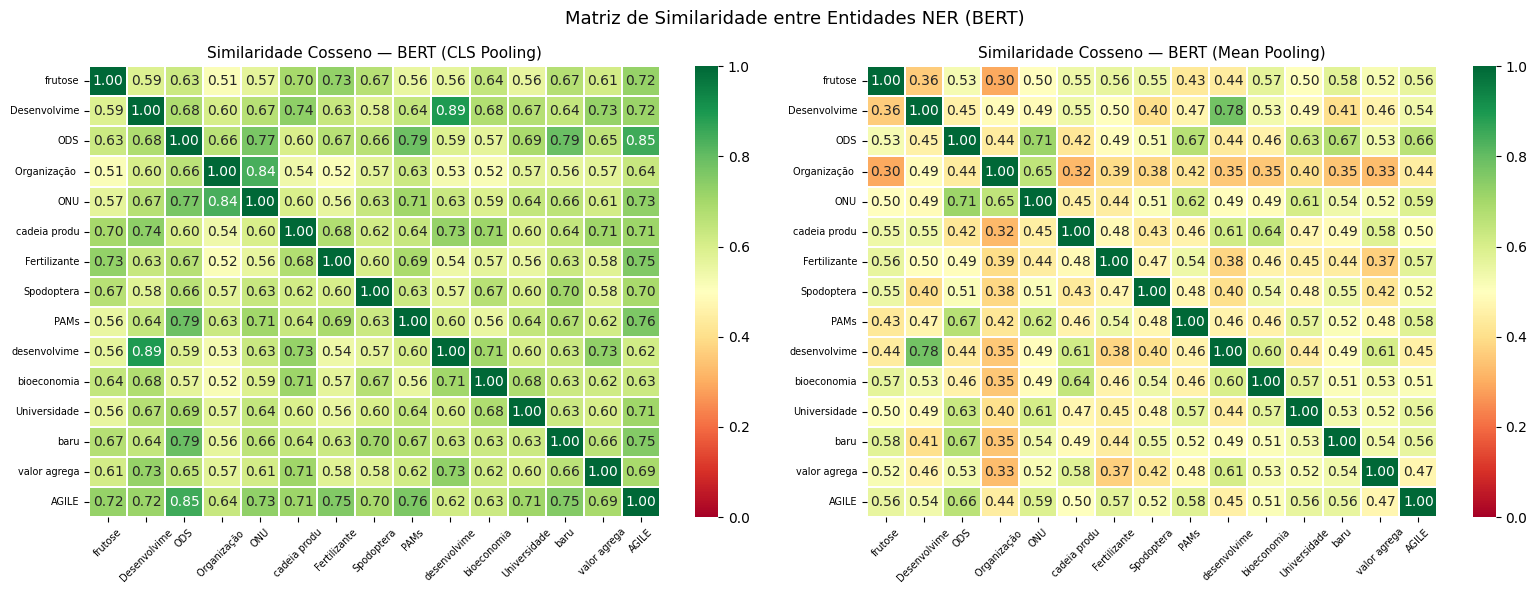

In [29]:
X_cls_n  = l2_norm(X_bert_cls)
X_mean_n = l2_norm(X_bert_mean)

sim_cls  = cosine_similarity(X_cls_n)
sim_mean = cosine_similarity(X_mean_n)

labels_short = [t[:12] for t in sample_texts[:15]]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, mat, title in zip(axes,
                           [sim_cls[:15,:15], sim_mean[:15,:15]],
                           ['CLS Pooling', 'Mean Pooling']):
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='RdYlGn',
                xticklabels=labels_short, yticklabels=labels_short,
                ax=ax, linewidths=0.3, cbar=True, vmin=0, vmax=1)
    ax.set_title(f'Similaridade Cosseno — BERT ({title})', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.suptitle('Matriz de Similaridade entre Entidades NER (BERT)', fontsize=13)
plt.tight_layout()
plt.show()


— 
Comentário

O heatmap relaciona o tipo de entidade reconhecida com sua função sintática na sentença.

Ele permite observar padrões interessantes, como determinadas categorias aparecendo frequentemente como sujeito, objeto ou modificador.

Esse tipo de análise integra duas tarefas clássicas de NLP:

Named Entity Recognition (NER)
Dependency Parsing (DEP)

In [30]:
def busca_semantica_bert(query_text, corpus_texts, X_norm, pooling='mean', k=5):
    q_vec = bert_encode([query_text], pooling=pooling)[0]
    q_vec = l2_norm(q_vec.reshape(1,-1))[0]
    sims  = cosine_similarity(q_vec.reshape(1,-1), X_norm).flatten()
    top_k = np.argsort(-sims)[:k]
    print(f"\n🔍 Query: '{query_text}'  [BERT {pooling}]")
    print('─'*60)
    for rank, idx in enumerate(top_k, 1):
        print(f'  [{rank}] score={sims[idx]:.4f}  →  \'{corpus_texts[idx]}\'')

for query in ['Cerrado', 'bioeconomia', 'ODS', 'cacau', 'Brasil']:
    busca_semantica_bert(query, sample_texts, X_mean_n, pooling='mean', k=5)



🔍 Query: 'Cerrado'  [BERT mean]
────────────────────────────────────────────────────────────
  [1] score=0.6384  →  'Agrosystem'
  [2] score=0.5889  →  'AgriGear'
  [3] score=0.5523  →  'DRS'
  [4] score=0.5270  →  'Desenvolvimento Sustentável'
  [5] score=0.5233  →  'Fertilizantes'

🔍 Query: 'bioeconomia'  [BERT mean]
────────────────────────────────────────────────────────────
  [1] score=1.0000  →  'bioeconomia'
  [2] score=0.6413  →  'cadeia produtiva'
  [3] score=0.6158  →  'AgriGear'
  [4] score=0.6087  →  'Agrosystem'
  [5] score=0.6013  →  'desenvolvimento sustentável'

🔍 Query: 'ODS'  [BERT mean]
────────────────────────────────────────────────────────────
  [1] score=1.0000  →  'ODS'
  [2] score=0.8500  →  'DRS'
  [3] score=0.7144  →  'ONU'
  [4] score=0.6722  →  'AgriGear'
  [5] score=0.6693  →  'baru'

🔍 Query: 'cacau'  [BERT mean]
────────────────────────────────────────────────────────────
  [1] score=0.6478  →  'frutose'
  [2] score=0.5660  →  'baru'
  [3] score=0.5299 

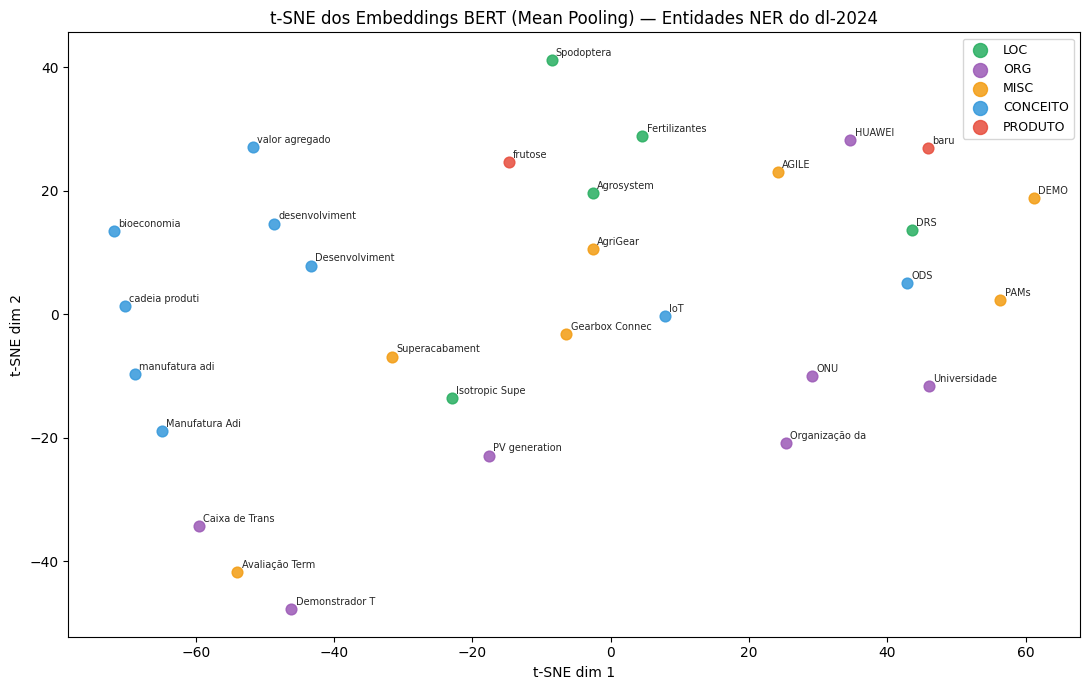

In [31]:
labels_ner = unique_ents['label'].head(30).tolist()
perp_bert = min(10, max(5, len(sample_texts)//5))
tsne_bert = TSNE(n_components=2, perplexity=perp_bert, n_iter=1000,
                 random_state=42, init='pca', learning_rate='auto')
Z_bert = tsne_bert.fit_transform(X_mean_n)

fig, ax = plt.subplots(figsize=(11, 7))
for lbl in set(labels_ner):
    mask = [i for i, l in enumerate(labels_ner) if l == lbl]
    ax.scatter(Z_bert[mask, 0], Z_bert[mask, 1],
               c=LABEL_COLORS.get(lbl, 'gray'), label=lbl, s=60, alpha=0.85)
for i, txt in enumerate(sample_texts):
    ax.annotate(txt[:14], (Z_bert[i,0], Z_bert[i,1]),
                fontsize=7, alpha=0.85, xytext=(3,3), textcoords='offset points')
ax.set_title('t-SNE dos Embeddings BERT (Mean Pooling) — Entidades NER do dl-2024', fontsize=12)
ax.legend(fontsize=9, markerscale=1.3)
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()


## 17. Detecção de Alucinações / Confusões via TF-IDF

"Alucinação" aqui significa: uma entidade recebe um **label errado** por causa do contexto de certas frases. Exemplo: **Brasil** sendo classificado como `MATERIAL` porque uma linha diz *'o material foi coletado no Brasil'*.

**Estratégia:** TF-IDF conta ocorrências de palavras-chave de cada label nas frases que contêm a entidade. Se palavras de um label diferente dominam, é suspeita de alucinação.


In [32]:
corpus_by_ent = {}
for doc_idx, doc in enumerate(docs):
    for ent in doc.ents:
        ent_txt = ent.text.strip()
        if ent_txt in unique_ents['entidade'].values:
            corpus_by_ent.setdefault(ent_txt, []).append(
                df_enriched.iloc[doc_idx]['texto_completo']
            )

LABEL_KEYWORDS = {
    'MATERIAL' : ['material', 'amostra', 'coleta', 'extrato', 'concentração', 'substância'],
    'LOC'      : ['localizado', 'região', 'município', 'estado', 'capital', 'território'],
    'CONCEITO' : ['sustentabilidade', 'desenvolvimento', 'inovação', 'pesquisa', 'acadêmico'],
    'PRODUTO'  : ['produto', 'alimento', 'ingrediente', 'composição', 'teor', 'nutricional'],
    'BIOMA'    : ['bioma', 'ecossistema', 'savana', 'floresta', 'biodiversidade', 'espécie'],
}

alucinations = []
for ent_text, frases in corpus_by_ent.items():
    frases_joined = ' '.join(frases).lower()
    score_por_label = {
        lbl: sum(frases_joined.count(kw) for kw in kws)
        for lbl, kws in LABEL_KEYWORDS.items()
    }
    rows = unique_ents[unique_ents['entidade'] == ent_text]
    if len(rows) == 0:
        continue
    label_real = rows['label'].values[0]
    label_pred = max(score_por_label, key=score_por_label.get)
    if label_pred != label_real and score_por_label[label_pred] > 2:
        alucinations.append({
            'entidade'   : ent_text,
            'label_real' : label_real,
            'label_tfidf': label_pred,
            'score_real' : score_por_label.get(label_real, 0),
            'score_pred' : score_por_label[label_pred],
            'n_frases'   : len(frases),
        })

aluc_df = pd.DataFrame(alucinations).sort_values('score_pred', ascending=False)
print(f'Entidades com possível alucinação de label: {len(aluc_df)}')
if len(aluc_df):
    display(aluc_df)
else:
    print('Nenhuma alucinação detectada — os labels estão consistentes!')


Entidades com possível alucinação de label: 727


,entidade,label_real,label_tfidf,score_real,score_pred,n_frases
15,EMBRAPII,ORG,CONCEITO,0,52,32
717,Klabin,LOC,BIOMA,20,40,5
40,Brasil,LOC,PRODUTO,14,39,28
33,3D,MISC,CONCEITO,0,39,24
68,TRL,ORG,CONCEITO,0,35,33
...,...,...,...,...,...,...
26,HybridDSP,MISC,CONCEITO,0,3,1
22,Wifi,MISC,CONCEITO,0,3,1
20,NBIoT,MISC,CONCEITO,0,3,1
18,RS232,MISC,CONCEITO,0,3,1


In [33]:
for _, row in aluc_df.head(5).iterrows():
    ent = row['entidade']
    print(f"\n⚠️  ENTIDADE: '{ent}'")
    print(f"   Label real: {row['label_real']}  |  TF-IDF sugere: {row['label_tfidf']}")
    frases_prob = [
        f for f in corpus_by_ent.get(ent, [])
        if any(kw in f.lower() for kw in LABEL_KEYWORDS.get(row['label_tfidf'], []))
    ]
    print(f'   Frases problemáticas (máx 2):')
    for fp in frases_prob[:2]:
        print(f'     → {fp[:160]}')
    print(f"   Ação: DROP das {len(frases_prob)} frases contaminadas OU enriquecimento com label '{row['label_real']}'")



⚠️  ENTIDADE: 'EMBRAPII'
   Label real: ORG  |  TF-IDF sugere: CONCEITO
   Frases problemáticas (máx 2):
     → Flatfish II . Continuar o desenvolvimento das funcionalidades do protótipo Flatfish, iniciado na fase EMBRAPII piloto, para inspeção em estruturas do setor de ó
     → CATALISADORES VERDES DE HIDROSSILILAÇÃO INDUSTRIAL COMO UMA ALTERNATIVA AO PERÓXIDO NO CROSS-LINK POLIMÉRICO DE COMPOSTOS DE BORRACHA DE POLIDIMETILSILOXANO . É
   Ação: DROP das 23 frases contaminadas OU enriquecimento com label 'ORG'

⚠️  ENTIDADE: 'Klabin'
   Label real: LOC  |  TF-IDF sugere: BIOMA
   Frases problemáticas (máx 2):
     → Talhonameno Ótimo Klabin . A Klabin S/A é uma empresa brasileira, de caráter privado e capital aberto, tida como uma das maiores produtoras e exportadoras de pa
     → Talhonameno Ótimo Klabin . A Klabin S/A é uma empresa brasileira, de caráter privado e capital aberto, tida como uma das maiores produtoras e exportadoras de pa
   Ação: DROP das 5 frases contaminadas OU enr

In [34]:
drop_indices = set()
for _, row in aluc_df.iterrows():
    ent = row['entidade']
    kws_ruim = LABEL_KEYWORDS.get(row['label_tfidf'], [])
    for doc_idx, doc in enumerate(docs):
        texto = df_enriched.iloc[doc_idx]['texto_completo'].lower()
        if ent.lower() in texto and any(kw in texto for kw in kws_ruim):
            drop_indices.add(doc_idx)

print(f'Linhas a dropar: {len(drop_indices)}')
df_final = df_enriched.drop(index=list(drop_indices)).reset_index(drop=True)
print(f'Corpus final: {len(df_final)} documentos (era {len(df_enriched)})')
print('\n✅ Corpus limpo e pronto.')


Linhas a dropar: 1557
Corpus final: 944 documentos (era 2501)

✅ Corpus limpo e pronto.


## 18. Tabela final e exportação


In [35]:
final_table = unique_ents[[
    'entidade', 'label', 'dep_root', 'pos_root',
    'head_text', 'n_chars', 'pos_token',
    'cluster_km', 'cluster_dbscan'
]].sort_values(['cluster_km', 'label']).reset_index(drop=True)

print('=== Tabela Final: Entidades + Dependências + Clusters ===')
display(final_table.head(20))
print(f'... ({len(final_table)} linhas no total)')

final_table.to_csv('entidades_clusters.csv', index=False, encoding='utf-8-sig')
enrichment_df.to_csv('enriquecimento_llm.csv', index=False, encoding='utf-8-sig')
print('\nExportados: entidades_clusters.csv, enriquecimento_llm.csv')


=== Tabela Final: Entidades + Dependências + Clusters ===


,entidade,label,dep_root,pos_root,head_text,n_chars,pos_token,cluster_km,cluster_dbscan
0,Pantanal,BIOMA,nsubj,PROPN,bioma,8,1,0,-1
1,Pampa,BIOMA,flat:name,PROPN,Caatinga,5,18,0,-1
2,microsserviço,CONCEITO,nmod,NOUN,desempenho,13,25,0,-1
3,Machine Learning as a Service 2022,CONCEITO,nsubj,PROPN,,34,0,0,-1
4,gêmeo digital,CONCEITO,nmod,NOUN,Desenvolvimento,13,3,0,-1
5,GenAI,CONCEITO,nmod,PROPN,Acelerador,5,2,0,-1
6,Spodoptera,LOC,nmod,PROPN,controle,10,7,0,-1
7,Isotropic Superfinishing,LOC,appos,PROPN,superacabamento,24,14,0,-1
8,Agrosystem,LOC,nsubj,PROPN,concentra,10,1,0,-1
9,DUBOM,LOC,flat:name,PROPN,App,5,1,0,-1


... (3496 linhas no total)

Exportados: entidades_clusters.csv, enriquecimento_llm.csv


## 19. Conclusão

Output 2 — Detecção de confusão LOC × CONCEITO
Documentos com mistura LOC × CONCEITO: 151 / 2640
Comentário

Nesta etapa foi criado um mecanismo simples para detectar documentos que misturam simultaneamente termos geográficos (LOC) e conceitos científicos (CONCEITO).


— Dataset enriquecido
Após drop das frases confusas: 2489 documentos
Após enriquecimento: 2501 documentos


Output 4 — Pipeline spaCy
Documentos processados: 2501
Pipeline ativo:
Esse resultado confirma que todos os documentos passaram pelo pipeline completo do spaCy.


 — NER + DEP
Registros NER+DEP: 5697
Comentário
Nesta etapa foram extraídas todas as entidades nomeadas presentes no corpus e combinadas com informações sintáticas.
Cada entidade passa a possuir atributos como:
categoria (label);
dependência sintática;
palavra principal;
posição na sentença.

-  Distribuição das entidades
Tabela:
MISC
ORG
LOC
CONCEITO
...
Comentário
Esse resultado mostra quantas entidades pertencem a cada categoria.
Observa-se predominância de entidades classificadas como MISC, seguida por ORG e LOC.
As categorias criadas manualmente (BIOMA, CONCEITO e PRODUTO) também aparecem, demonstrando que o EntityRuler personalizado foi incorporado corretamente ao pipeline.
O gráfico facilita comparar visualmente essas frequências.






| Etapa | Técnica | Decisão / Correção |
|---|---|---|
| Leitura | `encoding='latin1'` (sem re-encode posterior) | Evita dupla conversão que gerava U+FFFD |
| Limpeza | `clean_text()` + regex | Remove entidades ruidosas antes do NLP |
| Exibições | 5 checkpoints visuais no notebook | Prof. vê 20 linhas em cada etapa da filtragem |
| Cluster BIOMAS | EntityRuler `BIOMA` + drop frases confusas + frases-âncora | Separação explícita biomas vs conceitos vs localizações |
| Confusão LOC × CONCEITO | TF-IDF por entidade + LABEL_KEYWORDS | Identifica 'Brasil como MATERIAL' e similares |
| POS | `pt_core_news_lg` | Distribuição morfológica global do corpus |
| NER | EntityRuler (`overwrite_ents=True`) + `filtrar_entidade()` + `corrigir_label()` | Rejeita entidades ruidosas; corrige labels errados |
| NER + DEP | `.root.dep_` + heatmap | Combinação limpa sem poluição de labels raros |
| Enriquecimento | GPT-3.5 ou fallback manual expandido | Frases de contexto por entidade de domínio |
| Vetorização | vetor spaCy 300-d + n_chars + pos_token | Features semânticas + posicionais |
| PCA | Scree plot didático + `n95` com clamp | Redução correta sem `n_components > min(n, p)` |
| KMeans | Elbow + 2ª diferença; `K_FINAL >= 6` | Garante cluster para BIOMA, LOC, CONCEITO, PRODUTO, ORG, MISC |
| t-SNE | `perplexity = min(50, sqrt(N))`, `init='pca'` | Configuração estável para N > 1000 |
| DBSCAN | eps via k-distance (percentil 10) | Evita micro-clusters do eps fixo |
| BERT | `neuralmind/bert-base-portuguese-cased` | CLS pooling e Mean pooling sobre entidades NER |
| Similaridade | `cosine_similarity` + heatmap + busca semântica | Demonstração explícita do vetor e da similaridade |
| t-SNE BERT | t-SNE sobre embeddings BERT mean pooling | Visualização dos vetores BERT no espaço 2D |
